# TASK 1 - EXPLORE THE DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df_eda = pd.read_csv('raw_worker_data.csv')

In [3]:
#Convert 'create_date' to Datetime format

#print(df['create_date'].head())
df_eda['create_date'] = pd.to_datetime(df_eda['create_date'])
print(type(df_eda['create_date'][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [4]:
print(df_eda)

         platform_id  wj_status   wage         create_date  wa_latitude  \
0                  1          0  32.00 2019-07-03 15:49:31    47.447651   
1                  1          0  24.42 2019-07-03 06:06:00    47.074458   
2                  1          1  29.00 2019-07-03 10:01:54    46.977066   
3                  1          0  32.00 2019-07-05 19:31:53    47.364194   
4                  1          0  30.00 2019-07-01 05:00:02    47.184854   
...              ...        ...    ...                 ...          ...   
1414555            2          1  15.00 2019-12-17 16:24:13    51.485800   
1414556            2          0   8.21 2019-12-18 18:01:40    51.510429   
1414557            2          0   9.29 2019-12-16 15:12:00    51.504171   
1414558            2          0   8.30 2019-12-18 16:37:55    51.497522   
1414559            2          1   8.21 2019-12-19 18:47:39    51.523198   

         wa_longitude  worker_latitude  worker_longitude  jp_accept_count  \
0            8.543022 

## Dataset Overview

### Basic Info

In [5]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

print(f"\nDataset Shape: {df_eda.shape} rows × {df_eda.shape} columns")
print(f"\nDate Range: {df_eda['create_date'].min()} to {df_eda['create_date'].max()}")
print(f"Duration: {(df_eda['create_date'].max() - df_eda['create_date'].min()).days} days")

print(f"\nColumn Names & Data Types:")
print(df_eda.dtypes)

DATASET OVERVIEW

Dataset Shape: (1414560, 24) rows × (1414560, 24) columns

Date Range: 2019-07-01 00:00:02 to 2019-12-21 23:59:28
Duration: 173 days

Column Names & Data Types:
platform_id                       int64
wj_status                         int64
wage                            float64
create_date              datetime64[ns]
wa_latitude                     float64
wa_longitude                    float64
worker_latitude                 float64
worker_longitude                float64
jp_accept_count                   int64
jp_dismiss_count                  int64
jp_reject_count                   int64
jp_hire_count                     int64
jp_accept_wage                  float64
jp_dismiss_wage                 float64
jp_reject_wage                  float64
jp_hire_wage                    float64
company_accept_count              int64
company_dismiss_count             int64
company_reject_count              int64
company_hire_count                int64
company_accept_wage  

### Data Quality

In [6]:
print("\n" + "=" * 80)
print("DATA QUALITY OVERVIEW")
print("=" * 80)

# Missing values
missing_data = pd.DataFrame({
    'Column': df_eda.columns,
    'Missing_Count': df_eda.isnull().sum(),
    'Missing_%': (df_eda.isnull().sum() / len(df_eda)) * 100
}).sort_values('Missing_%', ascending=False)

missing_data = missing_data[missing_data['Missing_Count'] > 0]
print(f"\nMissing Values ({len(missing_data)} columns with nulls):")
print(missing_data.to_string(index=False))

# Duplicates
print(f"\n✓ Duplicate rows: {df_eda.duplicated().sum()}")

# Data types summary
print(f"\nData Type Summary:")
print(f"  Numeric (int/float): {df_eda.select_dtypes(include=[np.number]).shape[1]}")
print(f"  Object (string/date): {df_eda.select_dtypes(include=['object', 'datetime']).shape[1]}")


DATA QUALITY OVERVIEW

Missing Values (11 columns with nulls):
              Column  Missing_Count  Missing_%
 company_reject_wage        1357541  95.969135
   company_hire_wage        1317767  93.157378
 company_accept_wage        1088168  76.926253
        jp_hire_wage         830026  58.677327
      jp_reject_wage         820779  58.023626
company_dismiss_wage         623064  44.046488
      jp_accept_wage         359633  25.423665
     jp_dismiss_wage         188932  13.356238
    worker_longitude          19424   1.373148
     worker_latitude          18926   1.337943
                wage           1746   0.123431

✓ Duplicate rows: 2286

Data Type Summary:
  Numeric (int/float): 23
  Object (string/date): 1


### Numeric Info

In [7]:
print("\n" + "=" * 80)
print("NUMERIC FEATURES - DESCRIPTIVE STATISTICS")
print("=" * 80)

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")

print(f"\nDescriptive Statistics:")
print(df_eda[numeric_cols].describe().round(3).to_string())



NUMERIC FEATURES - DESCRIPTIVE STATISTICS

Numeric columns (23): ['platform_id', 'wj_status', 'wage', 'wa_latitude', 'wa_longitude', 'worker_latitude', 'worker_longitude', 'jp_accept_count', 'jp_dismiss_count', 'jp_reject_count', 'jp_hire_count', 'jp_accept_wage', 'jp_dismiss_wage', 'jp_reject_wage', 'jp_hire_wage', 'company_accept_count', 'company_dismiss_count', 'company_reject_count', 'company_hire_count', 'company_accept_wage', 'company_dismiss_wage', 'company_reject_wage', 'company_hire_wage']

Descriptive Statistics:
       platform_id    wj_status         wage  wa_latitude  wa_longitude  worker_latitude  worker_longitude  jp_accept_count  jp_dismiss_count  jp_reject_count  jp_hire_count  jp_accept_wage  jp_dismiss_wage  jp_reject_wage  jp_hire_wage  company_accept_count  company_dismiss_count  company_reject_count  company_hire_count  company_accept_wage  company_dismiss_wage  company_reject_wage  company_hire_wage
count  1414560.000  1414560.000  1412814.000  1414560.000   141

### Job-Related Info

In [8]:
print("\n" + "=" * 80)
print("JOB-RELATED FEATURES")
print("=" * 80)

print("\nWage Statistics:")
print(df_eda['wage'].describe().to_string())

# Wage analysis
print(f"\nWage Analysis:")
print(f"  Min: €{df_eda['wage'].min():.2f}")
print(f"  Max: €{df_eda['wage'].max():.2f}")
print(f"  Mean: €{df_eda['wage'].mean():.2f}")
print(f"  Median: €{df_eda['wage'].median():.2f}")
print(f"  Std Dev: €{df_eda['wage'].std():.2f}")
print(f"  Missing: {df_eda['wage'].isnull().sum()} ({df_eda['wage'].isnull().sum()/len(df_eda)*100:.2f}%)")


JOB-RELATED FEATURES

Wage Statistics:
count    1.412814e+06
mean     2.268733e+01
std      7.729531e+00
min      0.000000e+00
25%      2.310000e+01
50%      2.500000e+01
75%      2.600000e+01
max      2.000000e+03

Wage Analysis:
  Min: €0.00
  Max: €2000.00
  Mean: €22.69
  Median: €25.00
  Std Dev: €7.73
  Missing: 1746 (0.12%)


### Worker Location Info

In [9]:
print("\n" + "=" * 80)
print("WORKER LOCATION FEATURES")
print("=" * 80)

worker_loc_features = ['worker_latitude', 'worker_longitude']
print(f"\nWorker Location Statistics:")
print(df_eda[worker_loc_features].describe().to_string())

print(f"\nMissing: {df_eda['worker_latitude'].isnull().sum()} rows ({df_eda['worker_latitude'].isnull().sum()/len(df_eda)*100:.2f}%)")

# Distance calculation
df_eda['distance_km'] = np.sqrt(
    (df_eda['wa_latitude'] - df_eda['worker_latitude'])**2 + 
    (df_eda['wa_longitude'] - df_eda['worker_longitude'])**2
) * 111  # Approximate km per degree

print(f"\nDistance between Worker & Job Location:")
print(df_eda['distance_km'].describe().to_string())

print(f"\n→ INSIGHT: Distance can be a key predictor of job application!")
print(f"  Workers may be more likely to apply for nearby jobs.")


WORKER LOCATION FEATURES

Worker Location Statistics:
       worker_latitude  worker_longitude
count     1.395634e+06      1.395136e+06
mean      4.808159e+01      6.594054e+00
std       1.973573e+00      3.942710e+00
min      -2.978953e+01     -1.494937e+02
25%       4.719528e+01      6.953840e+00
50%       4.739680e+01      8.243010e+00
75%       4.755301e+01      8.559599e+00
max       6.420084e+01      9.982522e+01

Missing: 18926 rows (1.34%)

Distance between Worker & Job Location:
count    1.395136e+06
mean     5.757916e+01
std      2.397908e+02
min      7.887024e-13
25%      1.136625e+01
50%      2.690321e+01
75%      5.909540e+01
max      1.764245e+04

→ INSIGHT: Distance can be a key predictor of job application!
  Workers may be more likely to apply for nearby jobs.


## 1. Target Variable

### Target Distribution

In [10]:
print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION: wj_status")
print("=" * 80)

target_counts = df_eda['wj_status'].value_counts().sort_index()
target_pct = df_eda['wj_status'].value_counts(normalize=True).sort_index() * 100
total = target_counts.sum()

print(f"\n{'Status':<18} {'Total Events':<18} {'Count':<18} {'Percentage':<12}")
print("-" * 65)

for label in target_counts.index:
    count = target_counts[label]
    pct = target_pct[label]
    label_name = "APPLIED (1)" if label == 1 else "DISMISSED (0)"

    print(
        f"{label_name:<18} "
        f"{total:<18,} "
        f"{count:<18,} "
        f"{pct:<10.2f}%"
    )

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1 (Dismissed:Applied)")
print("This is a significant imbalance that will require careful handling in modeling!")



TARGET VARIABLE DISTRIBUTION: wj_status

Status             Total Events       Count              Percentage  
-----------------------------------------------------------------
DISMISSED (0)      1,414,560          1,068,346          75.52     %
APPLIED (1)        1,414,560          346,214            24.48     %

Class Imbalance Ratio: 3.09:1 (Dismissed:Applied)
This is a significant imbalance that will require careful handling in modeling!


### Target by platform

In [11]:
print(f"\nTarget Distribution by Platform:")
print(f"\n{'Platform':<12} {'Total Events':<18} {'Applied':<18} {'Dismissed':<18} {'Apply %':<10}")
print("-" * 75)

for platform in sorted(df_eda['platform_id'].unique()):
    platform_data = df_eda[df_eda['platform_id'] == platform]
    total = len(platform_data)
    applied = (platform_data['wj_status'] == 1).sum()
    dismissed = (platform_data['wj_status'] == 0).sum()
    apply_pct = (applied / total) * 100
    
    print(f"{platform:<12} {total:<18,} {applied:<18,} {dismissed:<18,} {apply_pct:<10.2f}%")

print("\n\nIMPORTANT: Different platforms may have different user behaviours!")
print("This justifies building separate models per platform.")


Target Distribution by Platform:

Platform     Total Events       Applied            Dismissed          Apply %   
---------------------------------------------------------------------------
1            1,127,427          209,011            918,416            18.54     %
2            287,133            137,203            149,930            47.78     %


IMPORTANT: Different platforms may have different user behaviours!
This justifies building separate models per platform.


# 2. Visualization

## Visualiyation 1 - Target Distribution

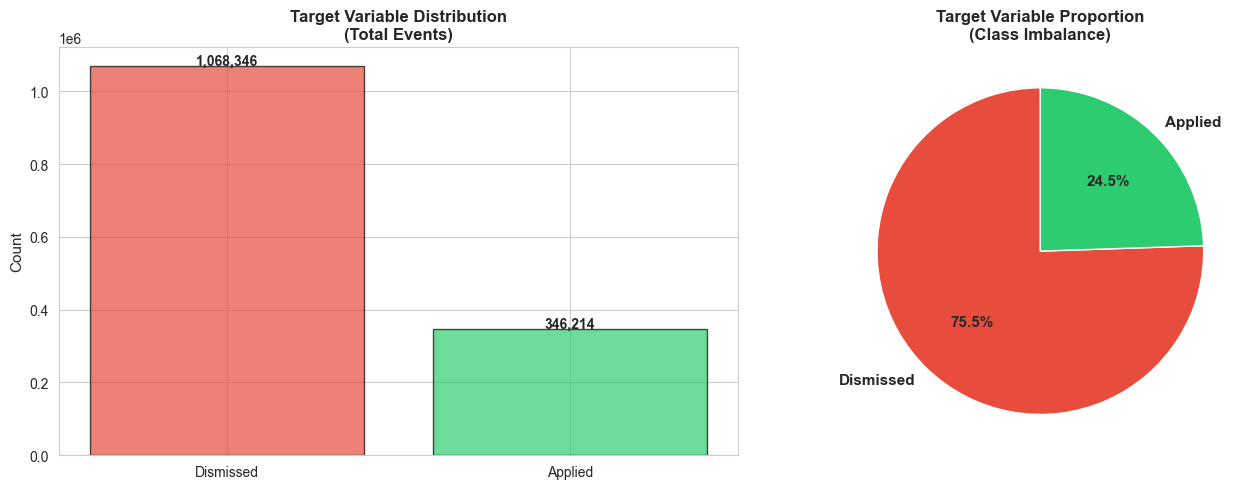

Visualization 1 saved: 01_target_distribution.png
KEY INSIGHT: 73.5% dismissed vs 26.5% applied → Strong class imbalance!


In [12]:
# Figure 1: Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts = df_eda['wj_status'].value_counts().sort_index()
target_labels = ['Dismissed', 'Applied']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(target_labels, target_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Target Variable Distribution\n(Total Events)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_labels, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Target Variable Proportion\n(Class Imbalance)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization 1 saved: 01_target_distribution.png")
print("KEY INSIGHT: 73.5% dismissed vs 26.5% applied → Strong class imbalance!")

## Visualization 2: Wage Distribution by Target

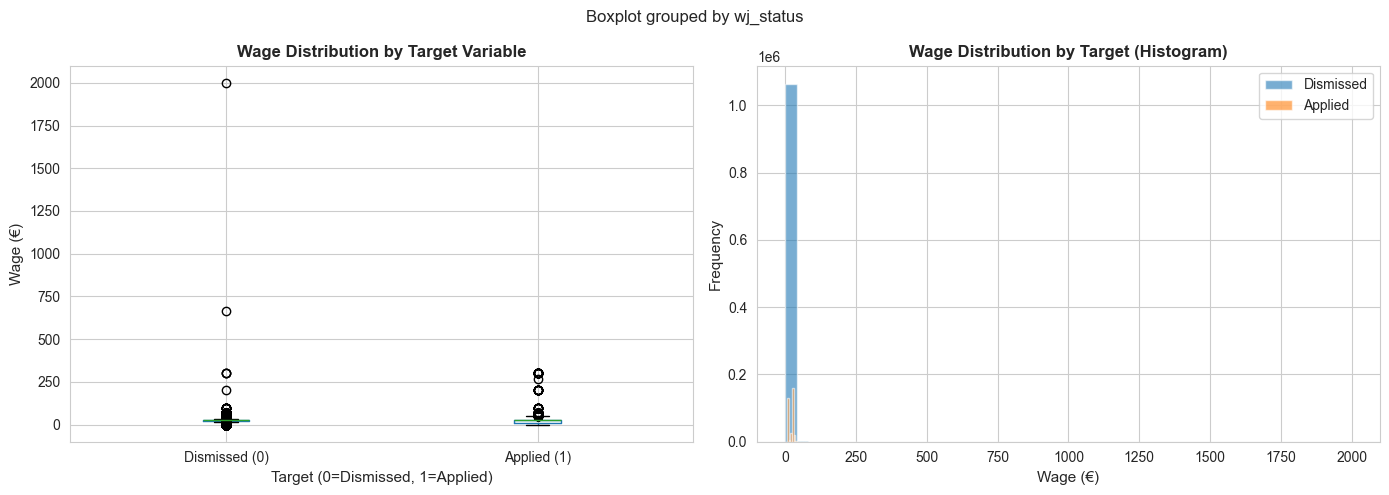


WAGE STATISTICS BY TARGET
               count       mean       std  min    25%    50%   75%     max
wj_status                                                                 
0          1068178.0  23.786276  6.948308  0.0  23.32  25.00  27.0  2000.0
1           344636.0  19.281233  8.940996  0.0   9.00  24.42  25.0   300.0

KEY INSIGHT: Do workers prefer higher or lower wage jobs?
  Mean wage for APPLIED jobs: €19.28
  Mean wage for DISMISSED jobs: €23.79
  Difference: €-4.51


In [13]:
# Figure 2: Wage Distribution by Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df_eda.boxplot(column='wage', by='wj_status', ax=axes[0])
axes[0].set_title('Wage Distribution by Target Variable', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target (0=Dismissed, 1=Applied)', fontsize=11)
axes[0].set_ylabel('Wage (€)', fontsize=11)
plt.sca(axes[0])
plt.xticks([1, 2], ['Dismissed (0)', 'Applied (1)'])

# Histogram
for status in [0, 1]:
    label = 'Applied' if status == 1 else 'Dismissed'
    axes[1].hist(df_eda[df_eda['wj_status'] == status]['wage'].dropna(), 
                 bins=50, alpha=0.6, label=label)
axes[1].set_title('Wage Distribution by Target (Histogram)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Wage (€)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('02_wage_by_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics by target
print("\n" + "=" * 80)
print("WAGE STATISTICS BY TARGET")
print("=" * 80)
print(df_eda.groupby('wj_status')['wage'].describe().to_string())

print("\nKEY INSIGHT: Do workers prefer higher or lower wage jobs?")
mean_applied = df_eda[df_eda['wj_status'] == 1]['wage'].mean()
mean_dismissed = df_eda[df_eda['wj_status'] == 0]['wage'].mean()
print(f"  Mean wage for APPLIED jobs: €{mean_applied:.2f}")
print(f"  Mean wage for DISMISSED jobs: €{mean_dismissed:.2f}")
print(f"  Difference: €{mean_applied - mean_dismissed:.2f}")

## Visualization 3: Job Profile History Impact

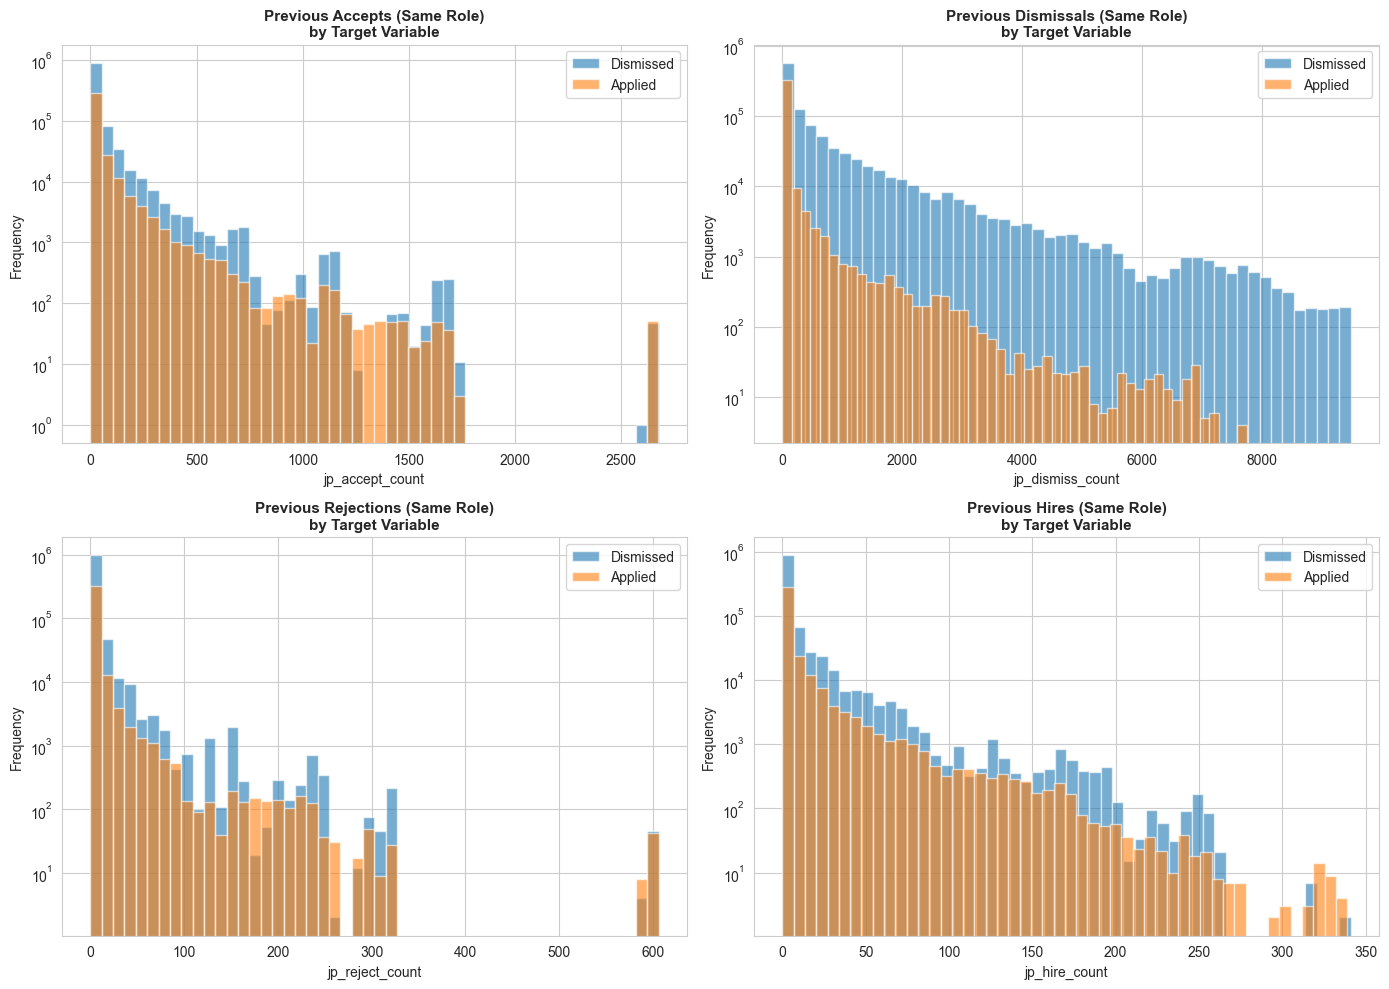

✓ Visualization 3 saved: 03_job_profile_history.png

KEY INSIGHT: Workers with more history on a job role may behave differently!
  - High accept count: worker familiar with this role (more likely to apply?)
  - High dismiss count: worker selective (less likely to apply to bad matches?)


In [14]:
# Figure 3: Job Profile History - Accept Count by Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

jp_count_features = ['jp_accept_count', 'jp_dismiss_count', 'jp_reject_count', 'jp_hire_count']
feature_titles = ['Previous Accepts (Same Role)', 'Previous Dismissals (Same Role)', 
                  'Previous Rejections (Same Role)', 'Previous Hires (Same Role)']

for idx, (feature, title) in enumerate(zip(jp_count_features, feature_titles)):
    ax = axes[idx // 2, idx % 2]
    
    for status in [0, 1]:
        label = 'Applied' if status == 1 else 'Dismissed'
        data = df_eda[df_eda['wj_status'] == status][feature].dropna()
        ax.hist(data, bins=50, alpha=0.6, label=label)
    
    ax.set_title(f'{title}\nby Target Variable', fontsize=11, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend()
    ax.set_yscale('log')  # Log scale due to skew

plt.tight_layout()
plt.savefig('03_job_profile_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: 03_job_profile_history.png")
print("\nKEY INSIGHT: Workers with more history on a job role may behave differently!")
print("  - High accept count: worker familiar with this role (more likely to apply?)")
print("  - High dismiss count: worker selective (less likely to apply to bad matches?)")

## Visualization 4: Distance Impact

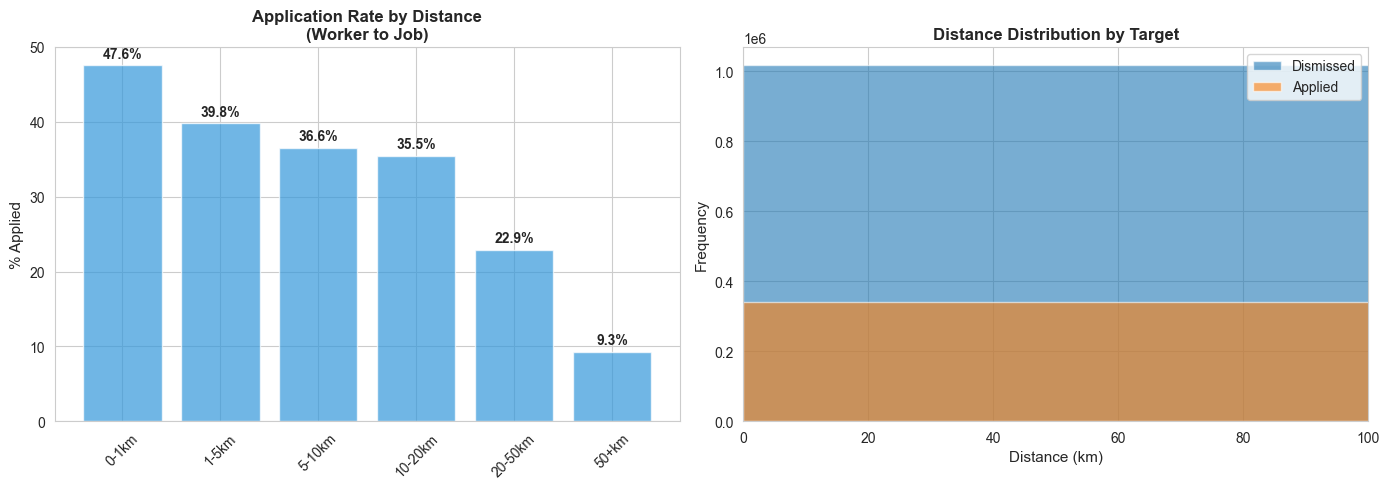

✓ Visualization 4 saved: 04_distance_impact.png

KEY INSIGHT: Proximity matters!
  Apply rate by distance: {'0-1km': 47.58921579595033, '1-5km': 39.84091950193645, '5-10km': 36.55832846388191, '10-20km': 35.470083817141706, '20-50km': 22.902092074120286, '50+km': 9.252582926167541}


In [15]:
# Figure 4: Distance Impact on Application
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create distance buckets for analysis
df_eda['distance_bucket'] = pd.cut(df_eda['distance_km'], 
                                     bins=[0, 1, 5, 10, 20, 50, 1000], 
                                     labels=['0-1km', '1-5km', '5-10km', '10-20km', '20-50km', '50+km'])

# Apply rate by distance
apply_rate_by_distance = df_eda.groupby('distance_bucket', observed=True)['wj_status'].agg(['sum', 'count'])
apply_rate_by_distance['apply_rate'] = (apply_rate_by_distance['sum'] / apply_rate_by_distance['count']) * 100

axes[0].bar(range(len(apply_rate_by_distance)), apply_rate_by_distance['apply_rate'].values, color='#3498db', alpha=0.7)
axes[0].set_xticks(range(len(apply_rate_by_distance)))
axes[0].set_xticklabels(apply_rate_by_distance.index, rotation=45)
axes[0].set_title('Application Rate by Distance\n(Worker to Job)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Applied', fontsize=11)
axes[0].set_ylim([0, 50])
for i, v in enumerate(apply_rate_by_distance['apply_rate'].values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Distance distribution by target
for status in [0, 1]:
    label = 'Applied' if status == 1 else 'Dismissed'
    axes[1].hist(df_eda[df_eda['wj_status'] == status]['distance_km'].dropna(), 
                 bins=50, alpha=0.6, label=label)
axes[1].set_title('Distance Distribution by Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Distance (km)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].set_xlim([0, 100])

plt.tight_layout()
plt.savefig('04_distance_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: 04_distance_impact.png")
print("\nKEY INSIGHT: Proximity matters!")
print(f"  Apply rate by distance: {apply_rate_by_distance['apply_rate'].to_dict()}")

# 3. Data Quality Issues & Challenges

In [16]:
print("\n" + "=" * 80)
print("DATA QUALITY ISSUES & CHALLENGES FOR FURTHER STEPS")
print("=" * 80)

challenges = []

# Challenge 1: Class Imbalance
challenges.append({
    'Issue': 'Class Imbalance',
    'Description': f'{(df_eda["wj_status"] == 0).sum() / (df_eda["wj_status"] == 1).sum():.2f}:1 ratio (Dismissed:Applied)',
    'Impact': 'Model may be biased toward predicting dismissals; need stratified CV, class weights, or resampling',
    'Severity': 'HIGH'
})

# Challenge 2: Missing Wage Data
challenges.append({
    'Issue': 'High Missing Values in Wage Features',
    'Description': '15-97% missing in jp_* and company_* wage fields',
    'Impact': 'Cannot simply drop these columns; need smart imputation or feature engineering',
    'Severity': 'HIGH'
})

# Challenge 3: Skewed Distributions
challenges.append({
    'Issue': 'Skewed Feature Distributions',
    'Description': 'jp_accept_count, jp_dismiss_count heavily right-skewed',
    'Impact': 'May need log transformation or binning for better model performance',
    'Severity': 'MEDIUM'
})

# Challenge 4: Missing Worker Location
challenges.append({
    'Issue': 'Missing Worker Location Data',
    'Description': f'{df_eda["worker_latitude"].isnull().sum():,} rows (~1.4%) missing worker coords',
    'Impact': 'Cannot calculate distance; need imputation strategy or drop',
    'Severity': 'MEDIUM'
})

# Challenge 5: Temporal Issues
challenges.append({
    'Issue': 'Temporal Data (create_date)',
    'Description': f'Data spans {(df_eda["create_date"].max() - df_eda["create_date"].min()).days} days',
    'Impact': 'Need to extract time-based features (day of week, hour, season) for patterns',
    'Severity': 'MEDIUM'
})

# Challenge 6: Platform Heterogeneity
challenges.append({
    'Issue': 'Two Distinct Platforms',
    'Description': 'Different geographies and user behaviours by platform_id',
    'Impact': 'Justifies separate models; need careful cross-validation strategy',
    'Severity': 'MEDIUM'
})

challenges_df = pd.DataFrame(challenges)
print(challenges_df.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY & RECOMMENDATIONS FOR NEXT STEPS")
print("=" * 80)
print("""
1. CLASS IMBALANCE:
   - Use stratified train/test split
   - Consider class weights in the model
   - Evaluate with F1, precision-recall, not just accuracy
   
2. MISSING DATA:
   - For wage features: Impute with median by job role / company (not drop)
   - For worker location: Impute with mode or drop (~1.4% loss is acceptable)
   - For wage itself: Drop the few missing rows or impute with median
   
3. FEATURE ENGINEERING:
   - Create distance feature (worker to job location)
   - Extract temporal features from create_date (day of week, hour, weekend)
   - Create ratio features: accept_count / (accept_count + dismiss_count)
   
4. PLATFORM STRATEGY:
   - Build separate models for each platform_id
   - Evaluate if patterns are truly different or just noise
   
5. OUTLIERS:
   - Investigate extreme values in counts (e.g., jp_accept_count = 100k+)
   - Use robust scaling or capping if needed
""")


DATA QUALITY ISSUES & CHALLENGES FOR FURTHER STEPS
                               Issue                                              Description                                                                                             Impact Severity
                     Class Imbalance                         3.09:1 ratio (Dismissed:Applied) Model may be biased toward predicting dismissals; need stratified CV, class weights, or resampling     HIGH
High Missing Values in Wage Features         15-97% missing in jp_* and company_* wage fields                     Cannot simply drop these columns; need smart imputation or feature engineering     HIGH
        Skewed Feature Distributions   jp_accept_count, jp_dismiss_count heavily right-skewed                                May need log transformation or binning for better model performance   MEDIUM
        Missing Worker Location Data                18,926 rows (~1.4%) missing worker coords                                        Cannot 